# Laboratorio 5.2: Regresion Logistica con PyTorch (Binaria)

**Basado en:** Lab_3.ipynb
**Dataset:** KDD Cup 99

# Secciones PyTorch obligatorias (nn, datasets, save)

Estas secciones deben estar presentes en cada Lab_5.x.

## Modelos secuenciales

Definimos redes con `nn.Sequential`.

In [ ]:
import torch
from torch import nn

modelo_secuencial = nn.Sequential(
    nn.Linear(4, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)
print(modelo_secuencial)

Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)


## Optimizadores y Funciones de perdida

Ejemplo de un paso de entrenamiento.

In [2]:
x_demo = torch.randn(16, 4)
y_demo = torch.randn(16, 1)

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(modelo_secuencial.parameters(), lr=0.01)

pred = modelo_secuencial(x_demo)
loss = loss_fn(pred, y_demo)
optimizer.zero_grad()
loss.backward()
optimizer.step()
print(f'Loss demo: {loss.item():.4f}')

Loss demo: 0.9911


## Modelos custom

Se define una clase que hereda de `nn.Module`.

In [3]:
class ModeloCustom(nn.Module):
    def __init__(self, in_features, hidden):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden, 1)

    def forward(self, x):
        x = self.act(self.fc1(x))
        return self.fc2(x)

modelo_custom = ModeloCustom(4, 8)
print(modelo_custom)

ModeloCustom(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (act): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


## Accediendo a las capas

Inspeccion de pesos y bias.

In [4]:
print('Pesos fc1:', modelo_custom.fc1.weight.shape)
print('Bias fc1:', modelo_custom.fc1.bias.shape)

Pesos fc1: torch.Size([8, 4])
Bias fc1: torch.Size([8])


## Iterando tensores

In [5]:
X_tensor = torch.randn(5, 3)
for i in range(len(X_tensor)):
    _ = X_tensor[i]

## Iterando por Batches

In [6]:
batch_size = 2
for i in range(0, len(X_tensor), batch_size):
    batch = X_tensor[i:i+batch_size]

## La clase Dataset

In [7]:
from torch.utils.data import Dataset, DataLoader

class DemoDataset(Dataset):
    def __init__(self, X):
        self.X = X
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx]

demo_ds = DemoDataset(X_tensor)
print('Len dataset:', len(demo_ds))

Len dataset: 5


## La clase DataLoader

In [8]:
demo_loader = DataLoader(demo_ds, batch_size=2, shuffle=True)
for batch in demo_loader:
    _ = batch

## Guardando modelos

Guardado del `state_dict`.

In [9]:
import os
save_dir = 'Lab/tmp_pytorch'
os.makedirs(save_dir, exist_ok=True)
torch.save(modelo_custom.state_dict(), os.path.join(save_dir, 'modelo_custom.pth'))

### Guardando los parametros

In [10]:
modelo_cargado = ModeloCustom(4, 8)
modelo_cargado.load_state_dict(torch.load(os.path.join(save_dir, 'modelo_custom.pth')))
modelo_cargado.eval()

ModeloCustom(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (act): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)

## Exportando modelos

### Torchscript

In [11]:
example_input = torch.randn(1, 4)
scripted = torch.jit.trace(modelo_custom, example_input)
scripted.save(os.path.join(save_dir, 'modelo_custom_scripted.pt'))

### ONNX

In [16]:
# Si onnx no esta instalado, comentar esta celda
# import torch.onnx
# torch.onnx.export(modelo_custom, example_input, os.path.join(save_dir, 'modelo_custom.onnx'),
#                   input_names=['input'], output_names=['output'], opset_version=11)

## Fase 1: Entender el dataset

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

data_path = '../Datasets/2_kddcup/kddcup.data_10_percent'
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
    'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
    'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label'
]
df = pd.read_csv(data_path, header=None, names=columns)
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal.' else 1)
for col in ['protocol_type', 'service', 'flag']:
    df[col] = pd.factorize(df[col])[0]
X = df.iloc[:, :-1].values.astype(np.float32)
y = df.iloc[:, -1].values.astype(np.float32)
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (494021, 41)
y shape: (494021,)


## Fase 2: Utilizacion y entrenamiento

Epoch 1/20 | Loss: 0.0832 | Acc: 98.71%
Epoch 2/20 | Loss: 0.0380 | Acc: 99.15%
Epoch 3/20 | Loss: 0.0298 | Acc: 99.17%
Epoch 4/20 | Loss: 0.0256 | Acc: 99.21%
Epoch 5/20 | Loss: 0.0232 | Acc: 99.25%
Epoch 6/20 | Loss: 0.0216 | Acc: 99.33%
Epoch 7/20 | Loss: 0.0204 | Acc: 99.48%
Epoch 8/20 | Loss: 0.0196 | Acc: 99.54%
Epoch 9/20 | Loss: 0.0190 | Acc: 99.57%
Epoch 10/20 | Loss: 0.0184 | Acc: 99.60%
Epoch 11/20 | Loss: 0.0181 | Acc: 99.63%
Epoch 12/20 | Loss: 0.0178 | Acc: 99.63%
Epoch 13/20 | Loss: 0.0176 | Acc: 99.64%
Epoch 14/20 | Loss: 0.0173 | Acc: 99.64%
Epoch 15/20 | Loss: 0.0171 | Acc: 99.65%
Epoch 16/20 | Loss: 0.0170 | Acc: 99.65%
Epoch 17/20 | Loss: 0.0168 | Acc: 99.65%
Epoch 18/20 | Loss: 0.0167 | Acc: 99.65%
Epoch 19/20 | Loss: 0.0166 | Acc: 99.66%
Epoch 20/20 | Loss: 0.0165 | Acc: 99.66%


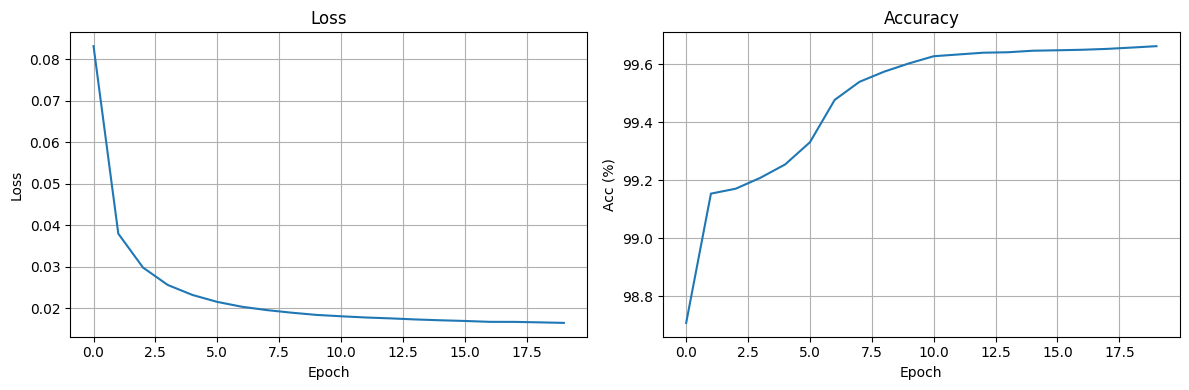

In [17]:
# Mezcla y split sin sklearn
m = y.size
indices = np.arange(m)
np.random.seed(42)
np.random.shuffle(indices)
X = X[indices]
y = y[indices]
train_size = int(0.8 * m)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Normalizacion
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma[sigma == 0] = 1
X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma

# DataLoader
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=512, shuffle=True)

# Modelo
model = nn.Linear(X_train.shape[1], 1)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# Entrenamiento
epochs = 20
loss_history = []
acc_history = []
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in train_loader:
        logits = model(xb)
        loss = loss_fn(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    avg_loss = total_loss / total
    acc = correct / total * 100
    loss_history.append(avg_loss)
    acc_history.append(acc)
    print(f'Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Acc: {acc:.2f}%')

# Graficos
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(acc_history)
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Acc (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Fase 3: Pruebas

In [18]:
model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)
with torch.no_grad():
    logits = model(X_test_t)
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()
    acc = (preds == y_test_t).float().mean().item() * 100
print(f'Accuracy en test: {acc:.2f}%')
print('Primeras 5 pred vs real:')
for i in range(5):
    print(int(preds[i].item()), int(y_test_t[i].item()))

Accuracy en test: 99.69%
Primeras 5 pred vs real:
1 1
1 1
1 1
1 1
0 0
